# Load Library

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Data Loading

In [2]:
df_nutrition = pd.read_csv('dish_nutrition_values.csv')

df_ingredients = pd.read_csv('ingredients_metadata.csv')

df_dish_ing = pd.read_csv('dish_ingredients.csv')

In [3]:
df_nutrition.head()

,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000


In [4]:
df_ingredients.head()

,ingr_name,ingr_id,cal/g,fat(g),carb(g),protein(g)
0,cottage cheese,ingr_0000000001,0.980,0.043,0.034,0.110
1,strawberries,ingr_0000000002,0.330,0.003,0.080,0.007
2,garden salad,ingr_0000000003,0.646,0.034,0.032,0.061
3,bacon,ingr_0000000004,5.410,0.420,0.014,0.370
4,potatoes,ingr_0000000005,0.770,0.001,0.170,0.020


In [5]:
df_dish_ing.head()

,dish_id,ingr_id,ingr_name,grams,calories,fat,carb,protein
0,dish_1561662216,ingr_0000000508,soy sauce,3.398568,1.801241,0.020391,0.166530,0.275284
1,dish_1561662216,ingr_0000000122,garlic,2.124105,3.164916,0.010621,0.700955,0.135943
2,dish_1561662216,ingr_0000000026,white rice,8.496420,11.045346,0.025489,2.378998,0.229403
3,dish_1561662216,ingr_0000000524,parsley,0.213397,0.079170,0.001707,0.013657,0.006189
4,dish_1561662216,ingr_0000000094,onions,1.707173,0.682869,0.001707,0.153646,0.018779


# Data Assesing

## 1. dish_nutrition_values.csv assesing data

In [6]:
df_nutrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4768 entries, 0 to 4767
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   dish_id   4768 non-null   object 
 1   calories  4768 non-null   float64
 2   mass      4768 non-null   float64
 3   fat       4768 non-null   float64
 4   carb      4768 non-null   float64
 5   protein   4768 non-null   float64
dtypes: float64(5), object(1)
memory usage: 223.6+ KB


In [7]:
df_nutrition.describe()

,calories,mass,fat,carb,protein
count,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000
mean,223.980835,191.429740,11.256767,17.851710,15.199094
std,312.583565,275.046928,24.938309,29.128902,18.728304
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,60.953761,72.000000,0.616000,5.120000,1.679974
50%,154.298584,145.000000,6.483000,12.712711,8.259001
75%,324.397980,260.000000,16.063000,24.200099,22.481344
max,9485.815430,7975.000000,875.541016,844.568604,147.491821


In [8]:
df_nutrition.duplicated().sum()

np.int64(0)

In [9]:
df_nutrition.isnull().sum()

dish_id     0
calories    0
mass        0
fat         0
carb        0
protein     0
dtype: int64

In [10]:
df_nutrition['calories'].value_counts()

calories
73.839996     16
74.360001     14
80.079994     10
16.020000      8
46.000000      7
              ..
352.395020     1
377.820007     1
240.425751     1
152.040009     1
137.569992     1
Name: count, Length: 4002, dtype: int64

In [11]:
df_nutrition[['calories','mass','fat','carb','protein']].corr()

,calories,mass,fat,carb,protein
calories,1.000000,0.484850,0.920769,0.681957,0.622442
mass,0.484850,1.000000,0.332770,0.490512,0.432018
fat,0.920769,0.332770,1.000000,0.456151,0.410218
carb,0.681957,0.490512,0.456151,1.000000,0.283308
protein,0.622442,0.432018,0.410218,0.283308,1.000000


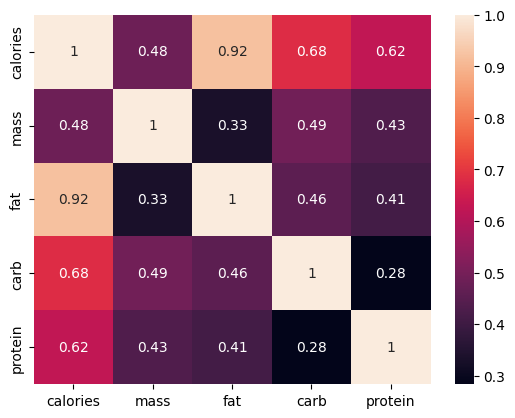

In [12]:
sns.heatmap(df_nutrition[['calories','mass','fat','carb','protein']].corr(), annot=True)
plt.show()

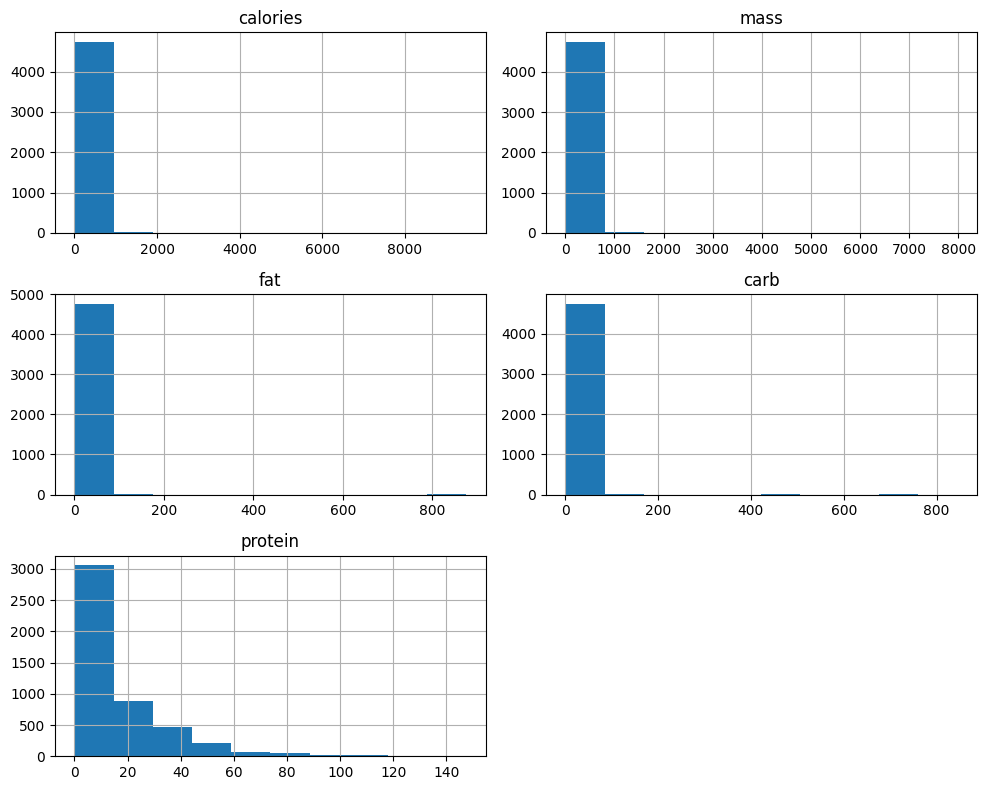

In [13]:
df_nutrition[['calories','mass','fat','carb','protein']].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [14]:
cols = ['calories','mass','fat','carb','protein']

for col in cols:
    Q1 = df_nutrition[col].quantile(0.25)
    Q3 = df_nutrition[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_nutrition[(df_nutrition[col] < lower) | (df_nutrition[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

calories: 128 outliers
mass: 129 outliers
fat: 180 outliers
carb: 168 outliers
protein: 205 outliers


## 2. ingredients_metadata.csv assessing data

In [15]:
df_ingredients.head()

,ingr_name,ingr_id,cal/g,fat(g),carb(g),protein(g)
0,cottage cheese,ingr_0000000001,0.980,0.043,0.034,0.110
1,strawberries,ingr_0000000002,0.330,0.003,0.080,0.007
2,garden salad,ingr_0000000003,0.646,0.034,0.032,0.061
3,bacon,ingr_0000000004,5.410,0.420,0.014,0.370
4,potatoes,ingr_0000000005,0.770,0.001,0.170,0.020


In [16]:
df_ingredients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ingr_name   555 non-null    object 
 1   ingr_id     555 non-null    object 
 2   cal/g       555 non-null    float64
 3   fat(g)      555 non-null    float64
 4   carb(g)     555 non-null    float64
 5   protein(g)  555 non-null    float64
dtypes: float64(4), object(2)
memory usage: 26.1+ KB


In [17]:
df_ingredients.describe()

,cal/g,fat(g),carb(g),protein(g)
count,555.000000,555.000000,555.000000,555.000000
mean,2.050568,0.102758,0.201297,0.086306
std,1.682599,0.159623,0.226562,0.092602
min,0.000000,0.000000,0.000000,0.000000
25%,0.608000,0.003000,0.036000,0.015000
50%,1.637000,0.035000,0.111000,0.051000
75%,3.062500,0.140000,0.270000,0.130000
max,9.033000,1.010000,1.000000,0.800000


In [18]:
df_ingredients.duplicated().sum()

np.int64(0)

In [19]:
df_ingredients.isnull().sum()

ingr_name     0
ingr_id       0
cal/g         0
fat(g)        0
carb(g)       0
protein(g)    0
dtype: int64

In [20]:
df_ingredients[['cal/g','fat(g)','carb(g)','protein(g)']].corr

<bound method DataFrame.corr of      cal/g  fat(g)  carb(g)  protein(g)
0    0.980   0.043    0.034       0.110
1    0.330   0.003    0.080       0.007
2    0.646   0.034    0.032       0.061
3    5.410   0.420    0.014       0.370
4    0.770   0.001    0.170       0.020
..     ...     ...      ...         ...
550  0.290   0.002    0.070       0.013
551  0.830   0.012    0.190       0.017
552  2.100   0.101    0.040       0.256
553  2.020   0.144    0.063       0.160
554  8.864   1.000    0.000       0.000

[555 rows x 4 columns]>

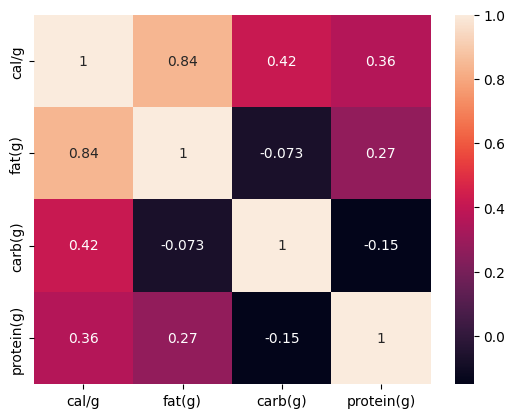

In [21]:
sns.heatmap(df_ingredients[['cal/g','fat(g)','carb(g)','protein(g)']].corr(), annot=True)
plt.show()

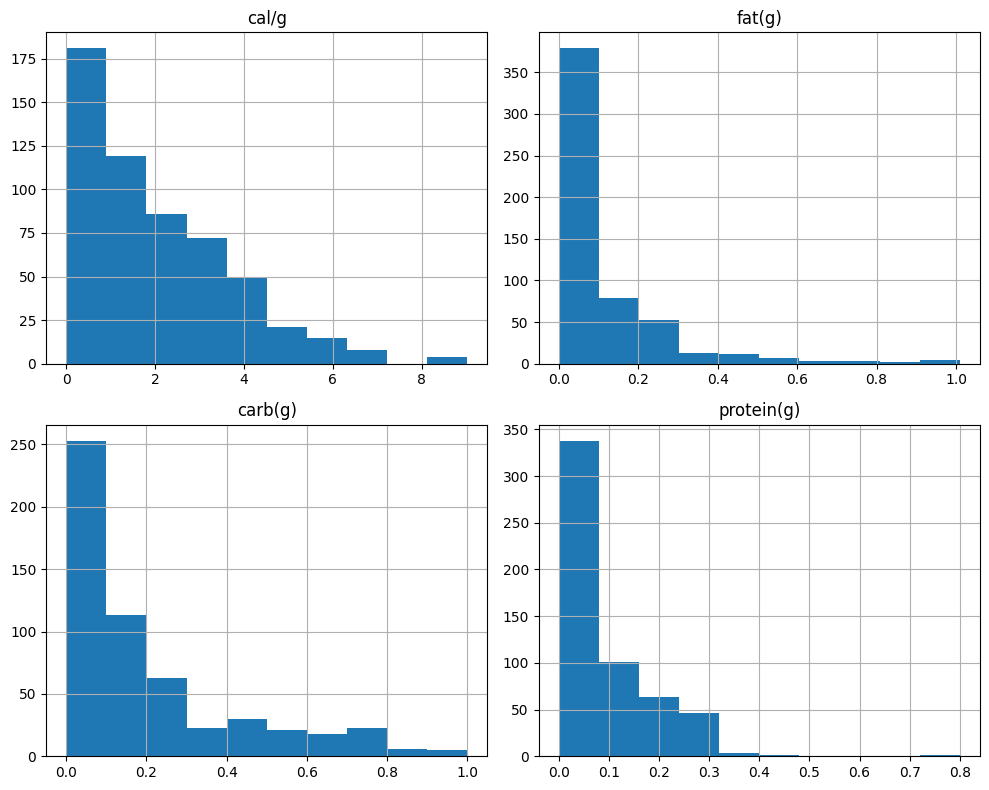

In [22]:
df_ingredients[['cal/g','fat(g)','carb(g)','protein(g)']].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [23]:
cols2 = ['cal/g','fat(g)','carb(g)','protein(g)']

for col in cols2:
    Q1 = df_ingredients[col].quantile(0.25)
    Q3 = df_ingredients[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_ingredients[(df_ingredients[col] < lower) | (df_ingredients[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

cal/g: 9 outliers
fat(g): 35 outliers
carb(g): 50 outliers
protein(g): 11 outliers


In [24]:
print(outliers)

           ingr_name          ingr_id  cal/g  fat(g)  carb(g)  protein(g)
3              bacon  ingr_0000000004  5.410   0.420    0.014       0.370
27           chicken  ingr_0000000028  1.650   0.036    0.000       0.310
77    protein powder  ingr_0000000078  4.000   0.033    0.100       0.800
147  parmesan cheese  ingr_0000000148  4.307   0.286    0.042       0.384
206    fried chicken  ingr_0000000207  2.461   0.118    0.019       0.304
213            seeds  ingr_0000000214  5.582   0.492    0.108       0.309
243   chicken breast  ingr_0000000244  1.652   0.036    0.000       0.311
285    romano cheese  ingr_0000000286  3.874   0.273    0.036       0.318
353         soy nuts  ingr_0000000354  4.490   0.220    0.290       0.430
434            jerky  ingr_0000000435  4.100   0.260    0.110       0.330
446   nutrition bars  ingr_0000000447  4.000   0.098    0.400       0.380


## 3. dish_ingredients.csv assessing data

In [25]:
df_dish_ing.head()

,dish_id,ingr_id,ingr_name,grams,calories,fat,carb,protein
0,dish_1561662216,ingr_0000000508,soy sauce,3.398568,1.801241,0.020391,0.166530,0.275284
1,dish_1561662216,ingr_0000000122,garlic,2.124105,3.164916,0.010621,0.700955,0.135943
2,dish_1561662216,ingr_0000000026,white rice,8.496420,11.045346,0.025489,2.378998,0.229403
3,dish_1561662216,ingr_0000000524,parsley,0.213397,0.079170,0.001707,0.013657,0.006189
4,dish_1561662216,ingr_0000000094,onions,1.707173,0.682869,0.001707,0.153646,0.018779


In [26]:
df_dish_ing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27225 entries, 0 to 27224
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   dish_id    27225 non-null  object 
 1   ingr_id    27225 non-null  object 
 2   ingr_name  27224 non-null  object 
 3   grams      27225 non-null  float64
 4   calories   27225 non-null  float64
 5   fat        27225 non-null  float64
 6   carb       27225 non-null  float64
 7   protein    27225 non-null  float64
dtypes: float64(5), object(3)
memory usage: 1.7+ MB


In [27]:
df_dish_ing.describe()

,grams,calories,fat,carb,protein
count,27225.000000,27225.000000,27225.000000,27225.000000,27225.000000
mean,34.400000,39.226469,1.971433,3.126426,2.661865
std,133.518285,125.498659,10.203751,12.231444,7.894871
min,0.012802,0.000000,0.000000,0.000000,0.000000
25%,1.219512,0.481118,0.003040,0.017484,0.010193
50%,7.515152,6.179065,0.056000,0.270766,0.142456
75%,50.978069,38.760000,0.652046,2.870000,1.034146
max,7974.000000,9170.100000,853.218000,837.480000,118.265700


In [28]:
df_dish_ing.duplicated().sum()

np.int64(0)

In [29]:
df_dish_ing.isnull().sum()

dish_id      0
ingr_id      0
ingr_name    1
grams        0
calories     0
fat          0
carb         0
protein      0
dtype: int64

In [30]:
miss_data = df_dish_ing[df_dish_ing.isnull().any(axis=1)]

In [31]:
print(miss_data)

               dish_id          ingr_id ingr_name  grams  calories  fat  carb  \
19286  dish_1568666357  ingr_0000000546       NaN    9.0      7.92  0.0  1.53   

       protein  
19286    0.045  


In [32]:
print(miss_data.index)

Index([19286], dtype='int64')


In [33]:
df_dish_ing[['grams','calories','fat','carb','protein']].corr

<bound method DataFrame.corr of           grams   calories       fat      carb   protein
0      3.398568   1.801241  0.020391  0.166530  0.275284
1      2.124105   3.164916  0.010621  0.700955  0.135943
2      8.496420  11.045346  0.025489  2.378998  0.229403
3      0.213397   0.079170  0.001707  0.013657  0.006189
4      1.707173   0.682869  0.001707  0.153646  0.018779
...         ...        ...       ...       ...       ...
27220  6.274510  55.466668  6.274510  0.000000  0.000000
27221  6.274510   0.627451  0.000000  0.125490  0.062745
27222  7.843138   2.117647  0.031373  0.368627  0.227451
27223  0.588235   0.876470  0.002941  0.194118  0.037647
27224  0.196078   0.000000  0.000000  0.000000  0.000000

[27225 rows x 5 columns]>

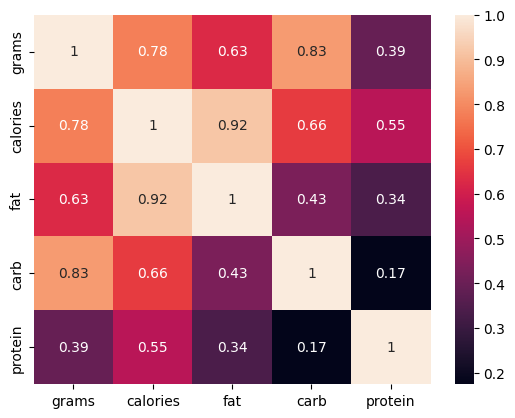

In [34]:
sns.heatmap(df_dish_ing[['grams','calories','fat','carb','protein']].corr(), annot=True)
plt.show()

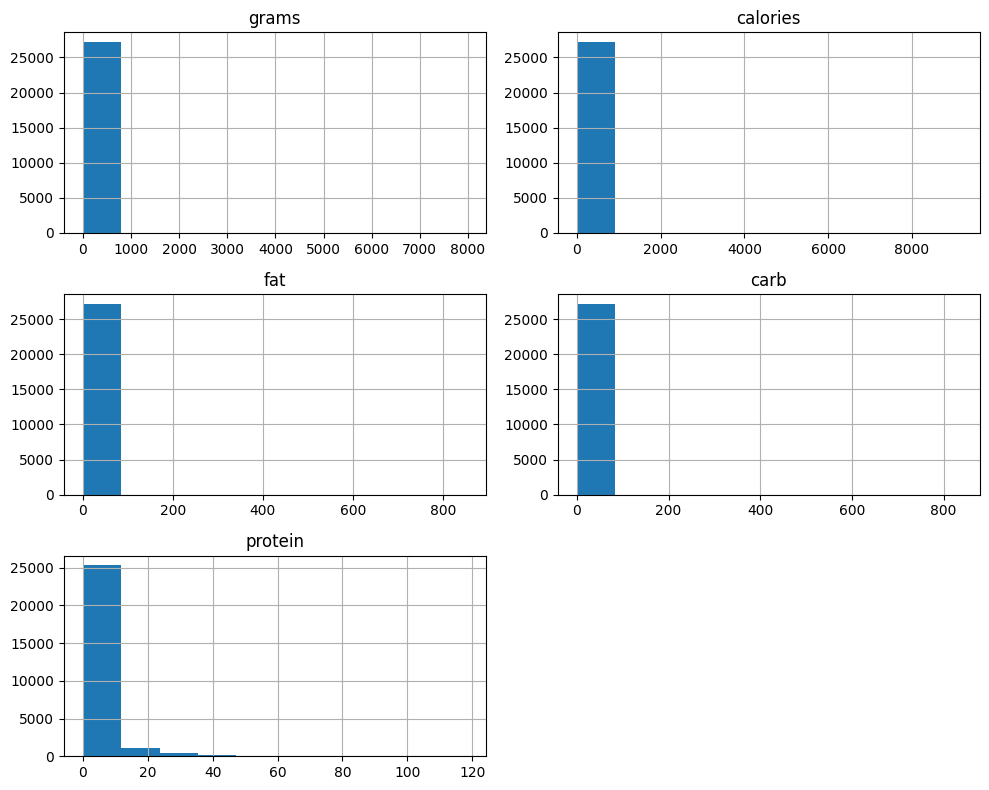

In [35]:
df_dish_ing[['grams','calories','fat','carb','protein']].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [36]:
cols3 = ['grams','calories','fat','carb','protein']

for col in cols3:
    Q1 = df_dish_ing[col].quantile(0.25)
    Q3 = df_dish_ing[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_dish_ing[(df_dish_ing[col] < lower) | (df_dish_ing[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

grams: 1304 outliers
calories: 3341 outliers
fat: 5597 outliers
carb: 3468 outliers
protein: 4351 outliers


# Cleaning Data

Menghapus satu Missing Value

In [37]:
df_dish_ing = df_dish_ing.drop(miss_data.index)

In [38]:
df_dish_ing.isnull().sum()

dish_id      0
ingr_id      0
ingr_name    0
grams        0
calories     0
fat          0
carb         0
protein      0
dtype: int64

Penanganan Outliers tidak dilakukan karena sampai saat ini outliers tersebut mengandung data yang faktual namun memang tidak memiliki jumlah data yang sepadan sehingga terdeteksi sebagai outliers menggunakan rumus IQR.
Penanganan akan dilakukan jika dalam pelatihan model nilai outliers ini mempengaruhi accuracy dari training dan testing model dan akan dipertimbangkan berdasarkan hasil dari training nantinya.

In [39]:
import os

base_path = "C:/My_Documents/Digdaya Hackathon/imagery/realsense_overhead"

def get_image_path(dish_id):
    return os.path.join(base_path, dish_id, "rgb.png")

df_nutrition["image_path"] = df_nutrition["dish_id"].apply(get_image_path)

df_nutrition.head()

,dish_id,calories,mass,fat,carb,protein,image_path
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,C:/My_Documents/Digdaya Hackathon/imagery/real...
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,C:/My_Documents/Digdaya Hackathon/imagery/real...
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,C:/My_Documents/Digdaya Hackathon/imagery/real...
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,C:/My_Documents/Digdaya Hackathon/imagery/real...
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,C:/My_Documents/Digdaya Hackathon/imagery/real...


In [40]:
df_ingr_grouped = df_dish_ing.groupby("dish_id").agg({
    "grams": "sum",
    "calories": "sum",
    "fat": "sum",
    "carb": "sum",
    "protein": "sum"
}).reset_index()

df_ingr_grouped.head()

,dish_id,grams,calories,fat,carb,protein
0,dish_1550704750,83.0,136.95,2.988,0.00,25.73
1,dish_1550704903,76.0,30.40,0.152,6.84,1.52
2,dish_1550705288,100.0,77.00,0.100,17.00,2.00
3,dish_1550705370,49.0,122.50,7.350,0.00,12.74
4,dish_1550705445,40.0,4.00,0.000,0.80,0.40


In [41]:
df_ingr_count = df_dish_ing.groupby("dish_id").size().reset_index(name="num_ingredients")

In [42]:
df_final = df_nutrition.merge(df_ingr_grouped, on="dish_id", suffixes=("", "_from_ingr"))
df_final = df_final.merge(df_ingr_count, on="dish_id")

In [43]:
df_final.head()

,dish_id,calories,mass,fat,carb,protein,image_path,grams,calories_from_ingr,fat_from_ingr,carb_from_ingr,protein_from_ingr,num_ingredients
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,C:/My_Documents/Digdaya Hackathon/imagery/real...,193.000002,300.794264,12.387491,28.218288,18.633969,17
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,C:/My_Documents/Digdaya Hackathon/imagery/real...,88.000000,137.570000,8.256000,5.190000,10.297000,2
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,C:/My_Documents/Digdaya Hackathon/imagery/real...,292.000009,419.438749,23.838249,26.351542,25.910592,17
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,C:/My_Documents/Digdaya Hackathon/imagery/real...,289.999995,382.936628,22.224641,10.173569,35.345386,13
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,C:/My_Documents/Digdaya Hackathon/imagery/real...,103.000000,20.590000,0.148000,4.625000,0.956000,3


In [44]:
import os

# 1. Ambil satu contoh path dari dataframe
sample_path = df_final['image_path'].iloc[0]

print(f"Path yang terdaftar: {sample_path}")
print(f"Apakah file benar-benar ada? {os.path.exists(sample_path)}")

# 2. Cek apakah ada masalah karakter (seperti spasi atau format slash)
# Jika kamu di Windows, terkadang butuh penyesuaian slash
print(f"Path setelah normalisasi: {os.path.normpath(sample_path)}")

Path yang terdaftar: C:/My_Documents/Digdaya Hackathon/imagery/realsense_overhead\dish_1561662216\rgb.png
Apakah file benar-benar ada? True
Path setelah normalisasi: C:\My_Documents\Digdaya Hackathon\imagery\realsense_overhead\dish_1561662216\rgb.png


In [45]:
from sklearn.model_selection import train_test_split

# 1. Split pertama: 80% Train dan 20% sisanya (untuk Val + Test)
df_train, df_temp = train_test_split(df_final, test_size=0.2, random_state=42)

# 2. Split kedua: Bagi 20% sisa tadi menjadi dua (10% Val dan 10% Test)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Jumlah Data Train: {len(df_train)}")
print(f"Jumlah Data Val: {len(df_val)}")
print(f"Jumlah Data Test: {len(df_test)}")

Jumlah Data Train: 3814
Jumlah Data Val: 477
Jumlah Data Test: 477


In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Gunakan resclaring
datagen = ImageDataGenerator(rescale=1./255)

target_cols = ['calories', 'fat', 'carb', 'protein']

# Penting: directory=None jika x_col berisi absolute path
train_gen = datagen.flow_from_dataframe(
    dataframe=df_train,
    directory=None,  # Tidak perlu folder tambahan
    x_col='image_path', 
    y_col=target_cols,
    target_size=(224, 224),
    batch_size=32,
    class_mode='other'
)

val_gen = datagen.flow_from_dataframe(
    dataframe=df_val,
    directory=None,
    x_col='image_path',
    y_col=target_cols,
    target_size=(224, 224),
    batch_size=32,
    class_mode='other'
)

test_gen = datagen.flow_from_dataframe(
    dataframe=df_test,
    directory=None,
    x_col='image_path',
    y_col=target_cols,
    target_size=(224, 224),
    batch_size=32,
    class_mode='other',
    shuffle=False
)

Found 2582 validated image filenames.
Found 334 validated image filenames.
Found 328 validated image filenames.


C:\ProgramData\miniconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1232 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(
C:\ProgramData\miniconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 143 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(
C:\ProgramData\miniconda3\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 149 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# 1. Load Base Model (MobileNetV2) tanpa layer atas
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze weights untuk tahap awal transfer learning

# 2. Membangun Arsitektur Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    # Output layer dengan 4 unit (Calories, Fat, Carb, Protein)
    # Gunakan aktivasi linear karena ini tugas regresi
    layers.Dense(4, activation='linear') 
])

# 3. Compile Model
model.compile(
    optimizer='adam',
    loss='mse', # Mean Squared Error cocok untuk regresi
    metrics=['mae'] # Mean Absolute Error untuk melihat rata-rata selisih prediksi
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,430,468 (9.27 MB)

 Trainable params: 172,484 (673.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Early Stopping: Berhenti jika val_loss tidak turun selama 5 epoch
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 2. Model Checkpoint: Simpan model terbaik berdasarkan val_loss terendah
checkpoint = ModelCheckpoint(
    'best_nutrition_model.h5', 
    monitor='val_loss', 
    save_best_only=True, 
    verbose=1
)

# Gabungkan dalam list
callbacks_list = [early_stop, checkpoint]

In [49]:
# Tentukan jumlah epoch yang diinginkan
EPOCHS = 50

history = model.fit(
    train_gen, # atau (X_train, y_train)
    validation_data=val_gen, # atau (X_val, y_val)
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

C:\ProgramData\miniconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - loss: 19167.8340 - mae: 63.9804 
Epoch 1: val_loss improved from inf to 10424.09766, saving model to best_nutrition_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 50s 586ms/step - loss: 19122.9922 - mae: 63.8965 - val_loss: 10424.0977 - val_mae: 46.5233
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - loss: 10553.2451 - mae: 42.1189 
Epoch 2: val_loss improved from 10424.09766 to 6753.24707, saving model to best_nutrition_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 49s 614ms/step - loss: 10527.0449 - mae: 42.0916 - val_loss: 6753.2471 - val_mae: 36.1748
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - loss: 5618.4380 - mae: 34.7492 
Epoch 3: val_loss improved from 6753.24707 to 5818.36377, saving model to best_nutrition_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 725ms/step - loss: 5633.8965 - mae: 34.7464 - val_loss: 5818.3638 - val_mae: 35.0690
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - loss: 7079.1587 - mae: 33.9175 
Epoch 4: val_loss improved from 5818.36377 to 5389.54150, saving model to best_nutrition_model.h5


...

81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 676ms/step - loss: 5306.3081 - mae: 26.4883 - val_loss: 4323.3564 - val_mae: 29.9690
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - loss: 5375.8843 - mae: 27.4276 
Epoch 12: val_loss improved from 4323.35645 to 4236.23730, saving model to best_nutrition_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 86s 726ms/step - loss: 5365.3530 - mae: 27.4179 - val_loss: 4236.2373 - val_mae: 28.3372
Epoch 13/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - loss: 4106.5806 - mae: 25.5928 
Epoch 13: val_loss improved from 4236.23730 to 4180.57764, saving model to best_nutrition_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 81s 717ms/step - loss: 4108.9795 - mae: 25.5957 - val_loss: 4180.5776 - val_mae: 29.0986
Epoch 14/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - loss: 2824.3081 - mae: 24.5077 
Epoch 14: val_loss improved from 4180.57764 to 4105.64307, saving model to best_nutrition_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 720ms/step - loss: 2840.0542 - mae: 24.5143 - val_loss: 4105.6431 - val_mae: 28.5897
Epoch 15/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - loss: 2983.3081 - mae: 24.6566 
Epoch 15: val_loss did not improve from 4105.64307
81/81 ━━━━━━━━━━━━━━━━━━━━ 58s 712ms/step - loss: 2996.8333 - mae: 24.6644 - val_loss: 4120.5991 - val_mae: 27.9034
Epoch 16/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - loss: 2756.4324 - mae: 24.5445 
Epoch 16: val_loss did not improve from 4105.64307
81/81 ━━━━━━━━━━━━━━━━━━━━ 78s 663ms/step - loss: 2770.5247 - mae: 24.5472 - val_loss: 4173.4844 - val_mae: 29.7551
Epoch 17/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - loss: 3103.8770 - mae: 24.2552 
Epoch 17: val_loss did not improve from 4105.64307
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 665ms/step - loss: 3112.1716 - mae: 24.2557 - val_loss: 4144.9351 - val_mae: 27.4999
Epoch 18/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - loss: 2899.3274 - mae: 23.2462 
Epoch 18: val_loss did not improve 

81/81 ━━━━━━━━━━━━━━━━━━━━ 59s 724ms/step - loss: 3048.7942 - mae: 23.6231 - val_loss: 3903.8271 - val_mae: 27.0907
Epoch 20/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - loss: 3550.9092 - mae: 23.1102 
Epoch 20: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 81s 717ms/step - loss: 3549.9255 - mae: 23.1168 - val_loss: 4002.5535 - val_mae: 26.8710
Epoch 21/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - loss: 4088.9429 - mae: 23.5107 
Epoch 21: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 713ms/step - loss: 4080.0232 - mae: 23.5037 - val_loss: 4052.0371 - val_mae: 28.6553
Epoch 22/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - loss: 3284.1445 - mae: 22.8872 
Epoch 22: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 78s 666ms/step - loss: 3283.9839 - mae: 22.8877 - val_loss: 3924.2859 - val_mae: 26.7146
Epoch 23/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - loss: 2930.6296 - mae: 21.9685 
Epoch 23: val_loss did not improve 

In [50]:
# 1. Unfreeze base_model
base_model.trainable = True

# 2. Re-compile dengan learning rate yang JAUH lebih kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5), # Sangat kecil (0.00001)
    loss='mse',
    metrics=['mae']
)

# 3. Latih kembali selama beberapa epoch
# history_fine = model.fit(...)

In [51]:
# Tentukan jumlah epoch yang diinginkan
EPOCHS = 50

history = model.fit(
    train_gen, # atau (X_train, y_train)
    validation_data=val_gen, # atau (X_val, y_val)
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 8703.6104 - mae: 39.1474   
Epoch 1: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - loss: 8695.4404 - mae: 39.1088 - val_loss: 4837.1709 - val_mae: 30.6517
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 5346.1440 - mae: 30.4016  
Epoch 2: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - loss: 5345.5786 - mae: 30.3931 - val_loss: 4585.3374 - val_mae: 29.8580
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 3830.8865 - mae: 25.7968  
Epoch 3: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - loss: 3833.0383 - mae: 25.8016 - val_loss: 4351.0195 - val_mae: 29.1870
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 2916.4265 - mae: 24.9238  
Epoch 4: val_loss did not improve from 3903.82715
81/81 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - loss: 2920.8518 - mae: 24.9175 - val_loss: 4316.2944 - val_mae: 28.7983
Epoch 5